https://www.kaggle.com/datasets/neurocipher/heartdisease

# **Doença Cardíaca**

# ⭐ Descrição do conjunto de dados

🫀 Este conjunto de dados contém informações clínicas e de estilo de vida usadas para avaliar o risco de doenças cardíacas em indivíduos. Cada linha representa um paciente e cada coluna captura um atributo médico que pode influenciar a saúde cardiovascular. O conjunto de dados é amplamente utilizado para tarefas de 🧠 classificação , 📊 análise exploratória de dados (EDA ) e 🤖 modelos de aprendizado de máquina voltados para a previsão de doenças cardíacas.

As características incluem detalhes demográficos, sinais vitais, níveis de colesterol, leituras de ECG, sintomas relacionados ao exercício e outros indicadores de saúde. Essas variáveis ​​ajudam a identificar padrões e a apoiar o diagnóstico precoce por meio de insights baseados em dados.

**Este conjunto de dados é adequado para:**

🤖 Modelos de classificação binária

📈 Análise exploratória de dados (EDA)

🩺 Projetos de avaliação de risco médico

⚙️ Engenharia de recursos e otimização de modelos

🎓 Prática de aprendizado de máquina para iniciantes e intermediários

# 📌 Colunas típicas (podem incluir):

👤 Idade – Idade do indivíduo

🚻 Sexo – Gênero (1 = masculino, 0 = feminino)

❤️‍🩹 Tipo de Dor no Peito – Tipo de dor no peito

🩸 PA em repouso – Pressão arterial em repouso

🧪 Colesterol – Nível de colesterol sérico

🍬 FastingBS – Glicemia em jejum (1 = alta, 0 = normal)

🧷 ECG em repouso – Resultados do ECG em repouso

🏃‍♂️ FCmáx – Frequência cardíaca máxima atingida

😣 Angina por exercício – Angina induzida por exercício

📉 Oldpeak – Depressão do segmento ST devido ao exercício

📐 ST_Slope – Inclinação do segmento ST

🎯 Doença cardíaca – Variável alvo (1 = doença, 0 = saudável)

# 🎯 Variável alvo
# Doença cardíaca

1 🟥 → Presença de doença cardíaca

0 🟩 → Sem doença cardíaca

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Heart_Disease_Prediction.csv')

# EDA

In [2]:
print(df.head())
print(df.info())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2                        0   

In [3]:
#Verificar valores ausentes
print(df.isnull().sum())

#Estatísticas principais
print(df.describe())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
              Age         Sex  Chest pain type          BP  Cholesterol  \
count  270.000000  270.000000       270.000000  270.000000   270.000000   
mean    54.433333    0.677778         3.174074  131.344444   249.659259   
std      9.109067    0.468195         0.950090   17.861608    51.686237   
min     29.000000    0.000000         1.000000   94.000000   126.000000   
25%     48.000000    0.000000         3.000000  120.000000   213.000000   
50%     55.000000    1.000000         3.000000  130.000000   245.000000   
75%     61.000000    1.000000         4.000000  140.0000

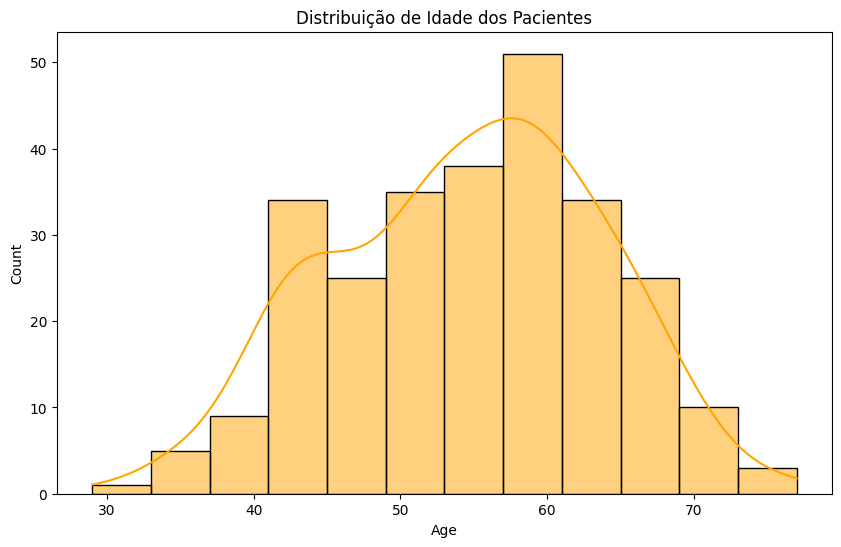

In [4]:
#Análise Univariada (Distribuições)
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='orange')
plt.title('Distribuição de Idade dos Pacientes')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_12556\152904406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y='Cholesterol', data=df, palette='flare')


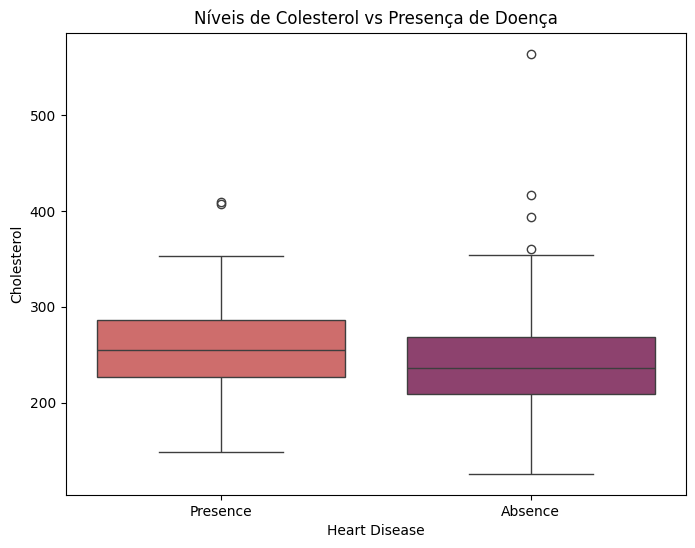

In [5]:
#Análise Bi-variada (Relações)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Heart Disease', y='Cholesterol', data=df, palette='flare')
plt.title('Níveis de Colesterol vs Presença de Doença')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_12556\259908073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Heart Disease', palette='viridis')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_12556\259908073.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y='Age', data=df, palette='Set2')


Text(0.5, 1.0, 'Matriz de Correlação (Corrigida)')

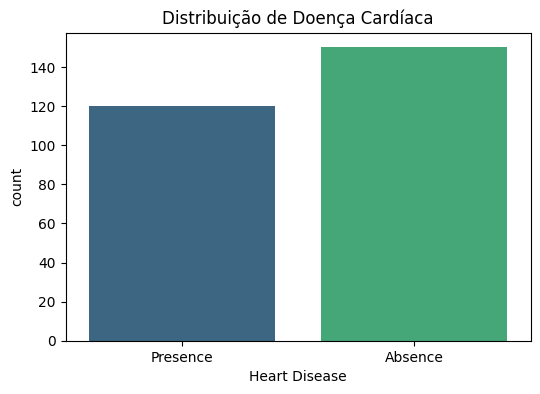

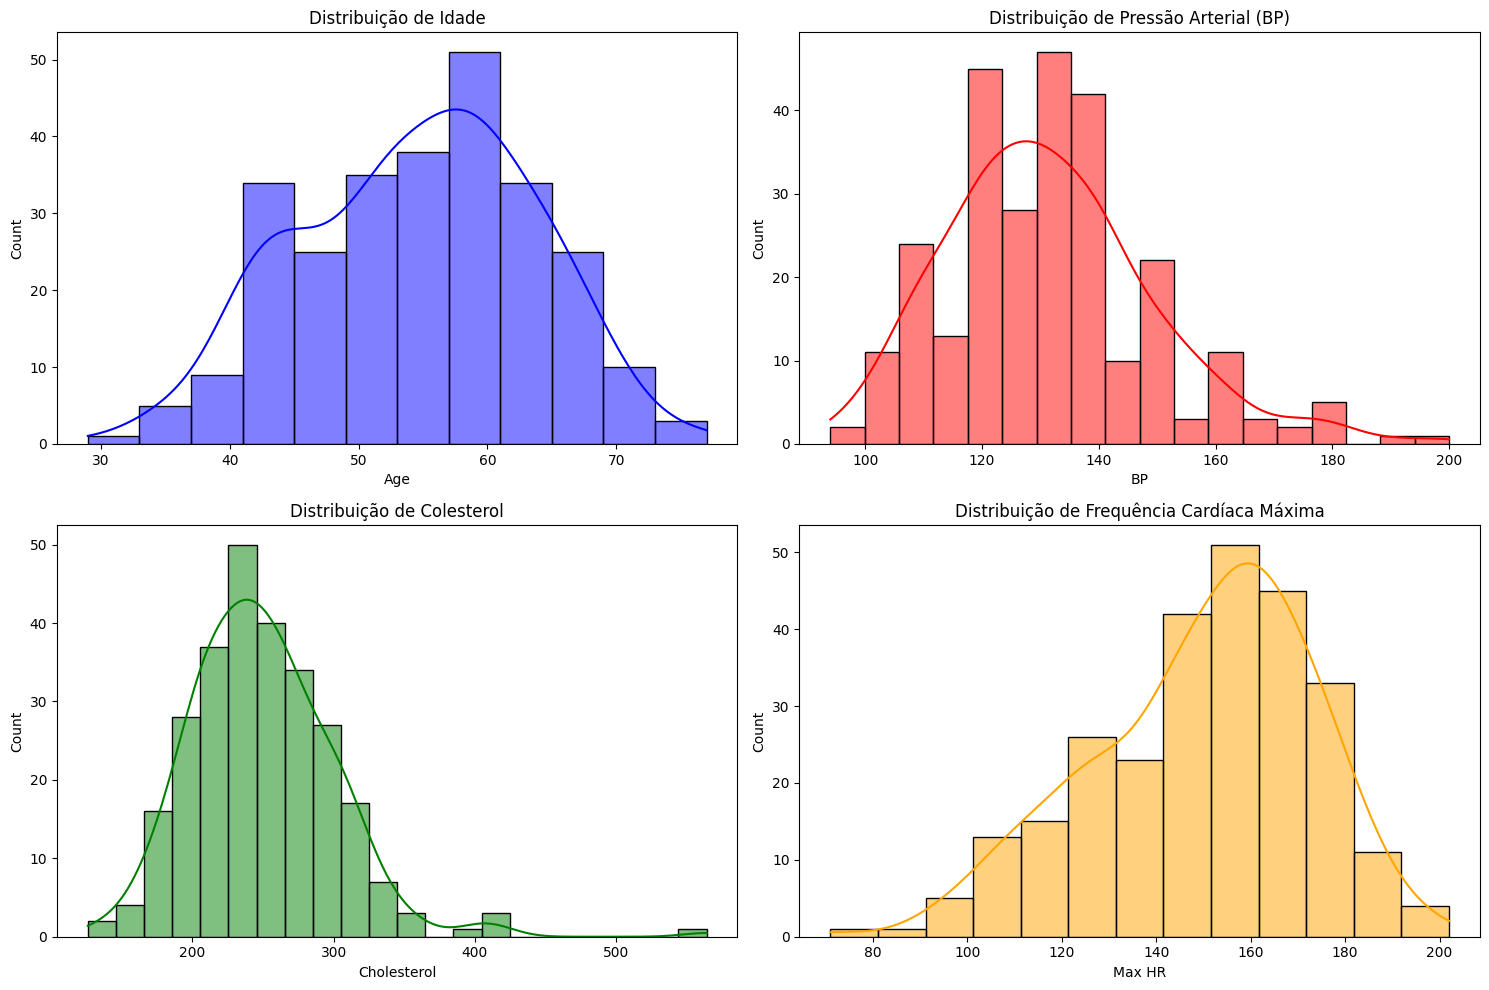

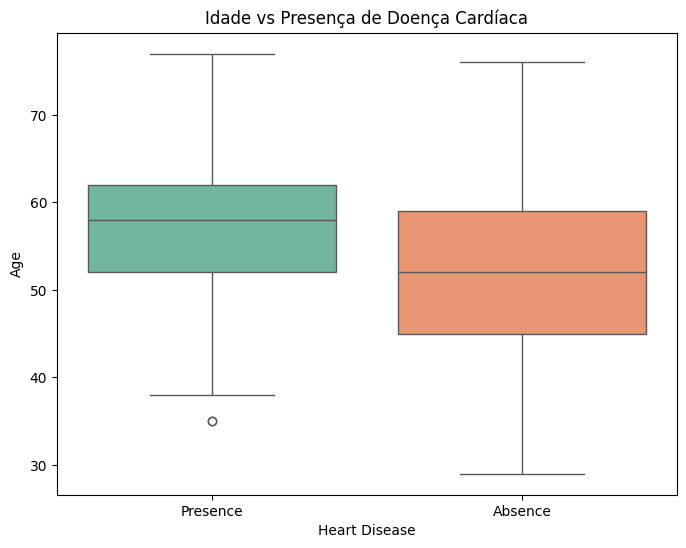

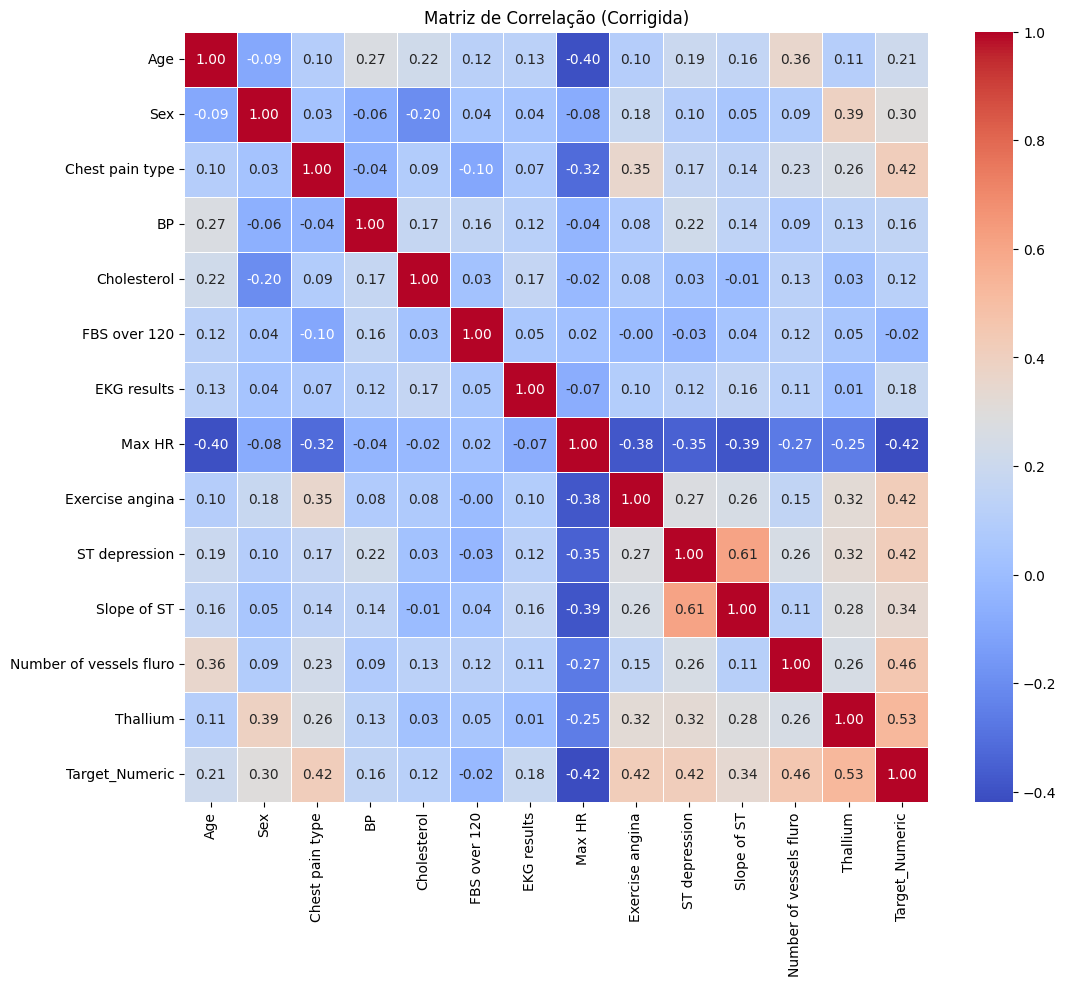

In [6]:
#Heatmap
df['Target_Numeric'] = df['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)

#Distribuição da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Heart Disease', palette='viridis')
plt.title('Distribuição de Doença Cardíaca')

#Distribuição de variáveis numéricas principais
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='blue').set_title('Distribuição de Idade')
sns.histplot(df['BP'], kde=True, ax=axes[0, 1], color='red').set_title('Distribuição de Pressão Arterial (BP)')
sns.histplot(df['Cholesterol'], kde=True, ax=axes[1, 0], color='green').set_title('Distribuição de Colesterol')
sns.histplot(df['Max HR'], kde=True, ax=axes[1, 1], color='orange').set_title('Distribuição de Frequência Cardíaca Máxima')
plt.tight_layout()

#Boxplot: Idade vs Doença
plt.figure(figsize=(8, 6))
sns.boxplot(x='Heart Disease', y='Age', data=df, palette='Set2')
plt.title('Idade vs Presença de Doença Cardíaca')

plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação (Corrigida)')

# ML

Acurácia: 83.33%
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.83      0.71      0.77        21

    accuracy                           0.83        54
   macro avg       0.83      0.81      0.82        54
weighted avg       0.83      0.83      0.83        54



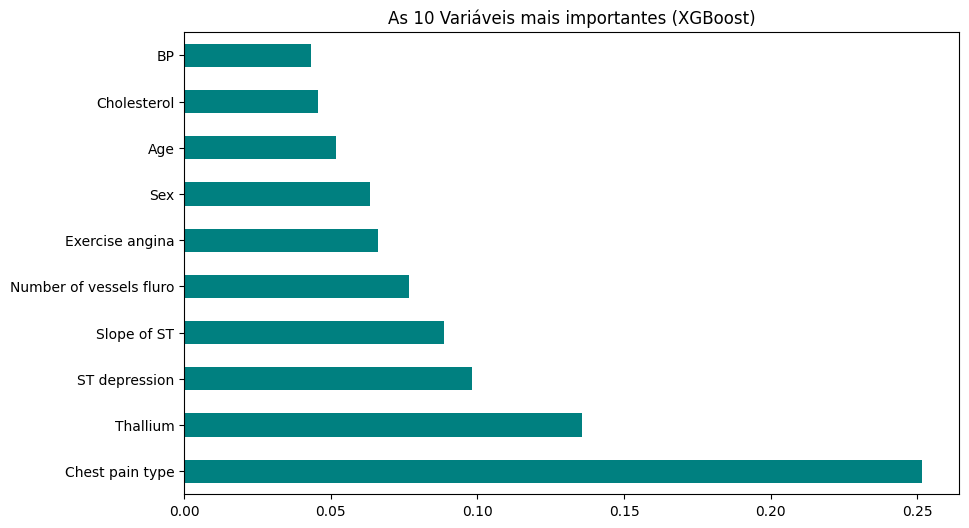

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(['Heart Disease', 'Target_Numeric'], axis=1)
y = df['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=4, 
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('As 10 Variáveis mais importantes (XGBoost)')
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5, # Cross-validation em 5 dobras
    verbose=1
)

grid_search.fit(X_train, y_train)

#Melhor combinação encontrada
print("Melhores Parâmetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:32] WARNING: C:\actions-runner\_w

Melhores Parâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:13:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 600x600 with 0 Axes>

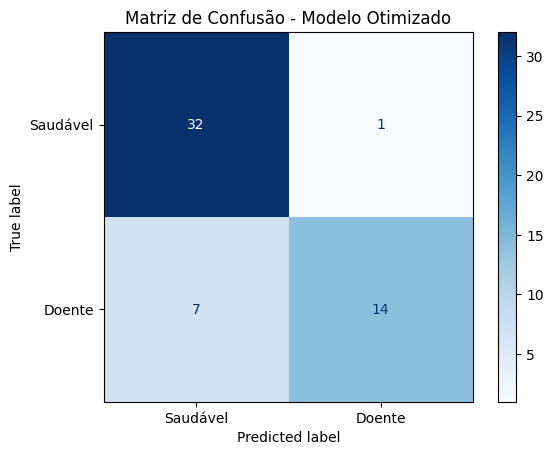

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Doente'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo Otimizado')
plt.show()

# Triagem

In [10]:
def avaliar_risco_paciente(modelo, dados_paciente):
    
    if not isinstance(dados_paciente, pd.DataFrame):
        dados_paciente = pd.DataFrame([dados_paciente])
    
    #Predição
    predicao = modelo.predict(dados_paciente)[0]
    probabilidade = modelo.predict_proba(dados_paciente)[0][1]
    
    print("=== RELATÓRIO DE AVALIAÇÃO DE RISCO ===")
    if predicao == 1:
        print(f"STATUS: ALTO RISCO (Presença de Doença)")
    else:
        print(f"STATUS: BAIXO RISCO (Ausência de Doença)")
    
    print(f"PROBABILIDADE CLÍNICA: {probabilidade:.2%}")
    print("=======================================")

exemplo = X_test.iloc[0]
avaliar_risco_paciente(model, exemplo)

=== RELATÓRIO DE AVALIAÇÃO DE RISCO ===
STATUS: BAIXO RISCO (Ausência de Doença)
PROBABILIDADE CLÍNICA: 19.01%


In [11]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

#Visualização para um paciente específico (ex: o primeiro do teste)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

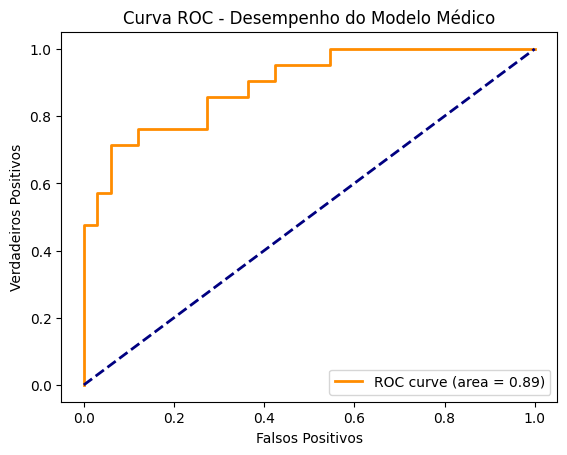

In [12]:
from sklearn.metrics import roc_curve, auc

#Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Curva ROC - Desempenho do Modelo Médico')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos')
plt.legend(loc="lower right")
plt.show()

# Power BI

In [13]:
import streamlit as st
import plotly.express as px
import joblib
from xgboost import XGBClassifier

# --- CONFIGURAÇÃO DA PÁGINA ---
st.set_page_config(page_title="CardioCheck AI", layout="wide")

# --- CARREGAMENTO DE DADOS E MODELO ---
@st.cache_data
def load_data():
    df = pd.read_csv('Heart_Disease_Prediction.csv')
    return df

df = load_data()
# Carregue o modelo que salvamos anteriormente
# model = joblib.load('modelo_risco_cardiaco_xgboost.pkl')

# --- SIDEBAR (FILTROS) ---
st.sidebar.header("Filtros de Análise")
idade_min, idade_max = st.sidebar.slider("Faixa Etária", 20, 80, (40, 60))
sexo = st.sidebar.multiselect("Gênero (1=M, 0=F)", options=[0, 1], default=[0, 1])

df_filtered = df[(df['Age'] >= idade_min) & (df['Age'] <= idade_max) & (df['Sex'].isin(sexo))]

# --- DASHBOARD PRINCIPAL ---
st.title("🩺 Dashboard de Avaliação de Risco Cardíaco")
st.markdown("Análise preditiva e apoio à decisão clínica baseada em Machine Learning.")

# Indicadores (KPIs)
col1, col2, col3 = st.columns(3)
col1.metric("Total de Pacientes", len(df_filtered))
col2.metric("Média de Colesterol", int(df_filtered['Cholesterol'].mean()))
col3.metric("Risco Médio (BP)", f"{df_filtered['BP'].mean():.1f} mmHg")

# --- GRÁFICOS INTERATIVOS ---
c1, c2 = st.columns(2)

with c1:
    st.subheader("Distribuição de Doença por Idade")
    fig_age = px.histogram(df_filtered, x="Age", color="Heart Disease", barmode="group", nbins=15)
    st.plotly_chart(fig_age, use_container_width=True)

with c2:
    st.subheader("Colesterol vs Frequência Cardíaca")
    fig_scatter = px.scatter(df_filtered, x="Cholesterol", y="Max HR", color="Heart Disease", size="Age")
    st.plotly_chart(fig_scatter, use_container_width=True)

# --- ÁREA DE PREDIÇÃO MÉDICA ---
st.divider()
st.subheader("🧠 Simulação de Paciente em Tempo Real")
col_p1, col_p2, col_p3 = st.columns(3)

with col_p1:
    st_age = st.number_input("Idade", 20, 100, 50)
    st_cp = st.selectbox("Tipo de Dor no Peito", [1, 2, 3, 4])
with col_p2:
    st_bp = st.number_input("Pressão Arterial", 80, 200, 120)
    st_thal = st.selectbox("Thallium", [3, 6, 7])
with col_p3:
    st_maxhr = st.number_input("Frequência Cardíaca Máx", 60, 220, 150)
    st_vessels = st.slider("Vasos Coloridos (Fluro)", 0, 3, 0)

if st.button("CALCULAR RISCO"):
    # Aqui entraria a chamada: model.predict(novos_dados)
    st.warning("Resultado: O modelo indica necessidade de acompanhamento para este perfil.")

2026-01-05 12:13:45.673 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-05 12:13:45.675 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-01-05 12:13:45.676 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-01-05 12:13:45.677 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-05 12:13:46.353 
  command:

    streamlit run c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-05 12:13:46.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-05 12:13:46.355 Thread 'MainThread': missing ScriptRunContext! This warning c

--- Visão Geral dos Dados ---
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  Target_Numeric  
0                        3         3      Presence               1  
1                   

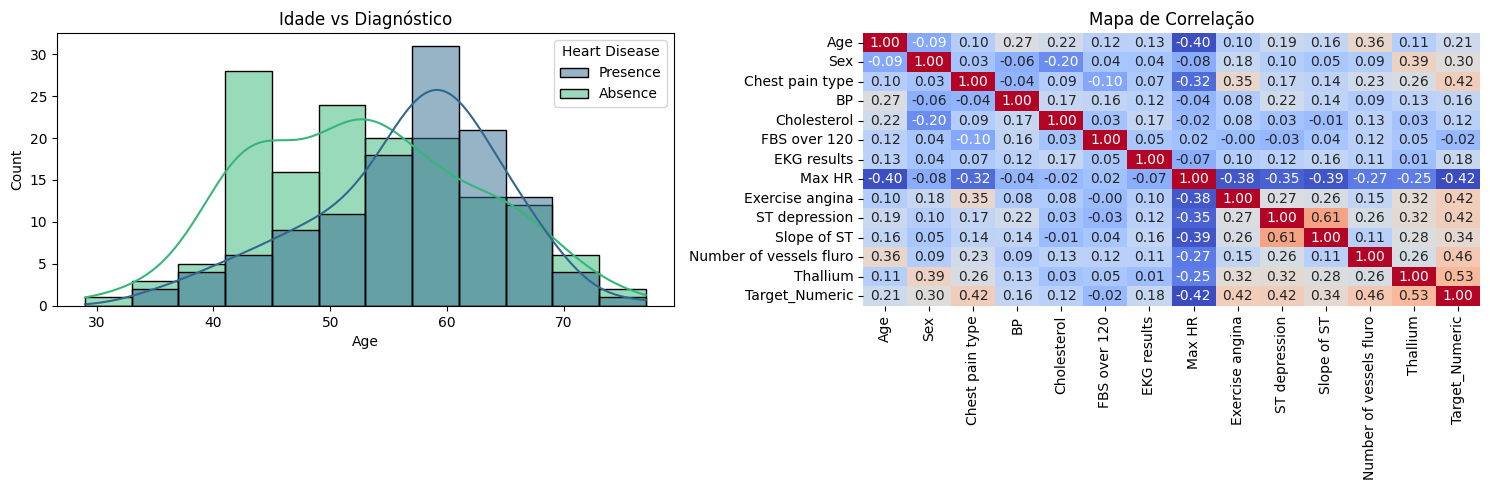


--- Resultados do Modelo (XGBoost) ---
Acurácia: 83.33%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.83      0.71      0.77        21

    accuracy                           0.83        54
   macro avg       0.83      0.81      0.82        54
weighted avg       0.83      0.83      0.83        54



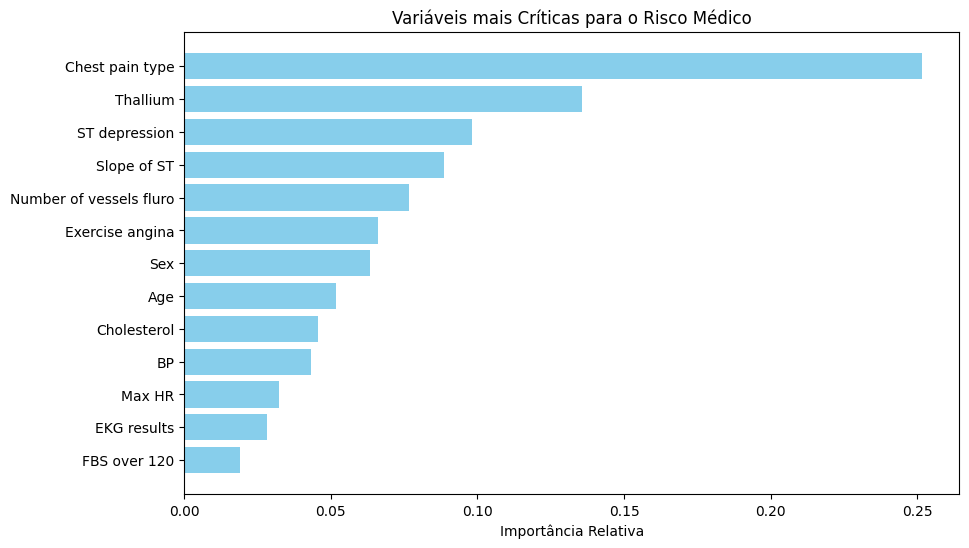


ANÁLISE DE RISCO: 99.74%
RESULTADO: ALTO RISCO (Encaminhar para Cardiologista)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. CARREGAMENTO E LIMPEZA
df = pd.read_csv('Heart_Disease_Prediction.csv')

# Criando versão numérica para o alvo (Machine Learning)
df['Target_Numeric'] = df['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)

print("--- Visão Geral dos Dados ---")
print(df.head())
print(f"\nValores Ausentes: {df.isnull().sum().sum()}")

# 2. ANÁLISE EXPLORATÓRIA (EDA)
def run_eda(df):
    plt.figure(figsize=(15, 5))
    
    # Gráfico 1: Distribuição de Idade por Doença
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='Age', hue='Heart Disease', kde=True, palette='viridis')
    plt.title('Idade vs Diagnóstico')
    
    # Gráfico 2: Matriz de Correlação
    plt.subplot(1, 2, 2)
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
    plt.title('Mapa de Correlação')
    
    plt.tight_layout()
    plt.show()

run_eda(df)

# 3. MODELAGEM (XGBOOST)
# Definindo Features e Target
X = df.drop(['Heart Disease', 'Target_Numeric'], axis=1)
y = df['Target_Numeric']

# Split Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configurando o Modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective='binary:logistic',
    random_state=42
)

# Treinamento
model.fit(X_train, y_train)

# 4. AVALIAÇÃO DO MODELO
y_pred = model.predict(X_test)

print("\n--- Resultados do Modelo (XGBoost) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 5. IMPORTÂNCIA DAS VARIÁVEIS (Apoio à Decisão)
def plot_importance(model, features):
    importance = pd.DataFrame({
        'Variável': features,
        'Importância': model.feature_importances_
    }).sort_values(by='Importância', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Variável'], importance['Importância'], color='skyblue')
    plt.title('Variáveis mais Críticas para o Risco Médico')
    plt.xlabel('Importância Relativa')
    plt.show()

plot_importance(model, X.columns)

# 6. FUNÇÃO DE PREDIÇÃO PARA NOVOS PACIENTES
def predizer_paciente(dados):
    # Converte dicionário para DataFrame
    df_paciente = pd.DataFrame([dados])
    prob = model.predict_proba(df_paciente)[0][1]
    
    print("\n" + "="*30)
    print(f"ANÁLISE DE RISCO: {prob:.2%}")
    if prob > 0.5:
        print("RESULTADO: ALTO RISCO (Encaminhar para Cardiologista)")
    else:
        print("RESULTADO: BAIXO RISCO (Monitoramento de Rotina)")
    print("="*30)

# Exemplo de teste com o Cursor
exemplo_paciente = {
    'Age': 58, 'Sex': 1, 'Chest pain type': 4, 'BP': 150, 
    'Cholesterol': 280, 'FBS over 120': 0, 'EKG results': 2, 
    'Max HR': 110, 'Exercise angina': 1, 'ST depression': 2.5, 
    'Slope of ST': 2, 'Number of vessels fluro': 2, 'Thallium': 7
}

predizer_paciente(exemplo_paciente)

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Carregamento e Preparação dos Dados
df = pd.read_csv('Heart_Disease_Prediction.csv')
df['Risk_Level'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# 2. Configuração do Layout do Dashboard (Subplots 3x2)
fig = make_subplots(
    rows=3, cols=2,
    column_widths=[0.6, 0.4],
    row_heights=[0.2, 0.4, 0.4],
    specs=[[{"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy"}, {"type": "domain"}],
           [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("", "", "<b>Distribuição de Risco por Idade</b>", 
                    "<b>Tipos de Dor no Peito</b>", 
                    "<b>Pressão Arterial vs Colesterol</b>", 
                    "<b>Depressão ST por Severidade</b>"),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# --- KPIs (CARTÕES INDICADORES) ---
fig.add_trace(go.Indicator(
    mode="number+delta",
    value=df['Risk_Level'].sum(),
    title={"text": "Casos Confirmados<br><span style='font-size:0.8em;color:gray'>Total de Pacientes: 270</span>"},
    domain={'x': [0, 0.5], 'y': [0.8, 1]}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=df['Cholesterol'].mean(),
    number={'suffix': " mg/dL"},
    title={"text": "Média de Colesterol Global"},
    domain={'x': [0.5, 1], 'y': [0.8, 1]}
), row=1, col=2)

# --- GRÁFICO 1: HISTOGRAMA DE IDADE (ÁREA) ---
fig.add_trace(go.Histogram(x=df[df['Heart Disease']=='Presence']['Age'], name='Risco+', marker_color='#E74C3C', opacity=0.75), row=2, col=1)
fig.add_trace(go.Histogram(x=df[df['Heart Disease']=='Absence']['Age'], name='Saudável', marker_color='#2ECC71', opacity=0.75), row=2, col=1)

# --- GRÁFICO 2: PIE CHART (SINTOMAS) ---
pain_labels = {1: 'Angina Típica', 2: 'Angina Atípica', 3: 'Dor Não Anginosa', 4: 'Assintomático'}
df_pain = df['Chest pain type'].map(pain_labels).value_counts()
fig.add_trace(go.Pie(labels=df_pain.index, values=df_pain.values, hole=.4, marker=dict(colors=['#34495E', '#3498DB', '#9B59B6', '#F1C40F'])), row=2, col=2)

# --- GRÁFICO 3: SCATTER PLOT (BP x CHOL) ---
fig.add_trace(go.Scatter(
    x=df['BP'], y=df['Cholesterol'], mode='markers',
    marker=dict(size=10, color=df['Risk_Level'], colorscale='Reds', showscale=False),
    text=df['Heart Disease']
), row=3, col=1)

# --- GRÁFICO 4: BOXPLOT (ST DEPRESSION - PREDIÇÃO MÉDICA) ---
fig.add_trace(go.Box(y=df[df['Heart Disease']=='Presence']['ST depression'], name='Risco+', marker_color='#E74C3C'), row=3, col=2)
fig.add_trace(go.Box(y=df[df['Heart Disease']=='Absence']['ST depression'], name='Saudável', marker_color='#2ECC71'), row=3, col=2)

# --- CUSTOMIZAÇÃO DO TEMA (ESTILO POWER BI DARK) ---
fig.update_layout(
    title_text="<b>DASHBOARD DE ANÁLISE PREDITIVA CARDIOVASCULAR</b>",
    title_font_size=24,
    template="plotly_dark",
    paper_bgcolor="#121212",
    plot_bgcolor="#121212",
    showlegend=True,
    height=1000,
    margin=dict(t=100, b=50, l=50, r=50)
)

fig.update_xaxes(title_text="Idade", row=2, col=1)
fig.update_xaxes(title_text="Pressão Arterial", row=3, col=1)
fig.update_yaxes(title_text="Colesterol", row=3, col=1)

# Conclusão

As doenças cardíacas não depende de um único fator, mas da combinação de indicadores bioquímicos e fisiológicos.
A principal extraída dos dados é que variáveis como idade avançada combinada com níveis elevados de depressão ST.

# **Nathália Sorg**